# 🩺 **DIABETIC RETINOPATHY SCREENING SYSTEM**
### Automated Retinal Image Grading for Tele-Ophthalmology

---

### 📌 Project Overview
This project implements an **AI-based screening system** that analyzes retinal fundus images to detect **Diabetic Retinopathy (DR)** severity levels.  

The system uses a **Convolutional Neural Network (CNN)** to classify retinal images into **five stages** of diabetic retinopathy.

DR is an eye disease caused by long-term diabetes that damages the blood vessels in the retina (the light-sensitive tissue at the back of the eye).
---

### 🎯 Objectives
- Detect diabetic retinopathy from retinal images
- Classify disease severity into **five grades**
- Provide **AI-assisted screening for rural healthcare**
- Generate **medical insights and visual analysis**

---

### 📊 DR Classification Levels

| Grade | Condition |
|------|-----------|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |**bold text**
| 3 | Severe |
| 4 | Proliferative DR |

In [11]:
!pip install kaggle
!pip install opencv-python

# Pandas library is used for handling tabular data such as CSV files

In [8]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/sic_project/Dataset/train.csv")
data.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


# Image Preprocessing Function


In [9]:
import cv2
import numpy as np

IMG_SIZE = 224

def preprocess_image(path):

    img = cv2.imread(path)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    img = img/255.0

    return img


OpenCV is used for image loading and basic image processing

NumPy is used for numerical operations on image arrays

 CNN models require images of fixed dimensions.

 This function performs preprocessing on each retinal image before it is given to the deep learning model.

 Steps performed:
 1. Load the image from the given file path
 2. Resize the image to the required input size (224x224)
 3. Normalize pixel values to the range [0,1]


# Loading and Preprocessing Retinal Images


In [14]:
images = []
labels = []

for index,row in data.head(2000).iterrows():

    path = "/content/drive/MyDrive/sic_project/train_images/" + row['id_code'] + ".png"

    img = preprocess_image(path)

    images.append(img)
    labels.append(row['diagnosis'])

X = np.array(images)
y = np.array(labels)
np.save("/content/drive/MyDrive/sic_project/X_data.npy", X)
np.save("/content/drive/MyDrive/sic_project/y_data.npy", y)


In this section, retinal images are loaded from the dataset directory,preprocessed,

 and converted into NumPy arrays for training the
 deep learning model.

In [1]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/sic_project/my_model1.keras")

ModuleNotFoundError: No module named 'tensorflow'

X - contains all the preprocessed retina images.

Y- labels (0,1,3,0 ,1,2)

In [2]:
import numpy as np

X = np.load("/content/drive/MyDrive/sic_project/X_data.npy")
y = np.load("/content/drive/MyDrive/sic_project/y_data.npy")

# Convert Labels into One-Hot Encoding
Keras API inside TensorFlow

to_categorical() converts integer class labels into one-hot encoded vectors.
Original Label → One Hot Encoding

0 → [1 0 0 0 0]

1 → [0 1 0 0 0]

2 → [0 0 1 0 0]

3 → [0 0 0 1 0]

4 → [0 0 0 0 1]

In [3]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y,5)

Full Dataset

     │
     ├── Training Data (80%) → Train Model
     │
     └── Testing Data (20%) → Evaluate Model
After splitting:

X_train → training images

X_test → testing images

y_train → training labels

y_test → testing labels

In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2
)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNNs are particularly effective for image analysis because they can automatically learn spatial features such as edges, textures, and shapes directly from images.

For retinal images, CNNs can detect important medical indicators such as:

microaneurysms

hemorrhages

exudates

abnormal blood vessel growth

This makes CNNs highly suitable for medical image classification tasks like diabetic retinopathy detection.

Working Principle (Simple)

Retinal image is input to the CNN.

Convolution layers extract visual features.

Pooling layers reduce dimensionality while preserving key patterns.

Fully connected layers analyze these features.

Softmax layer predicts the severity class of diabetic retinopathy.

#Model Compilation

In [6]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

This step configures the CNN model for training by defining how the model will learn and evaluate its performance.

learning_rate = 0.0001

A smaller learning rate helps the model learn more gradually and prevents unstable training.

#Model Training
The model.fit() function trains the CNN model using the training dataset

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - accuracy: 0.5469 - loss: 1.2125 - val_accuracy: 0.6375 - val_loss: 0.9599
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.6877 - loss: 0.8738 - val_accuracy: 0.6700 - val_loss: 0.8859
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7194 - loss: 0.7734 - val_accuracy: 0.6925 - val_loss: 0.8603
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7251 - loss: 0.7399 - val_accuracy: 0.6775 - val_loss: 0.8503
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7172 - loss: 0.7329 - val_accuracy: 0.7025 - val_loss: 0.8491
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7313 - loss: 0.7408 - val_accuracy: 0.7150 - val_loss: 0.8078
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7357 - loss: 0.7056 - val_accuracy: 0.7150 - val_loss: 0.8119
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7486 - loss: 0.6919 - val_accuracy: 0.6900 -

In [9]:
model.save("/content/drive/MyDrive/sic_project/my_model1.keras")


In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7264 - loss: 0.8646
Test Accuracy: 0.7149999737739563


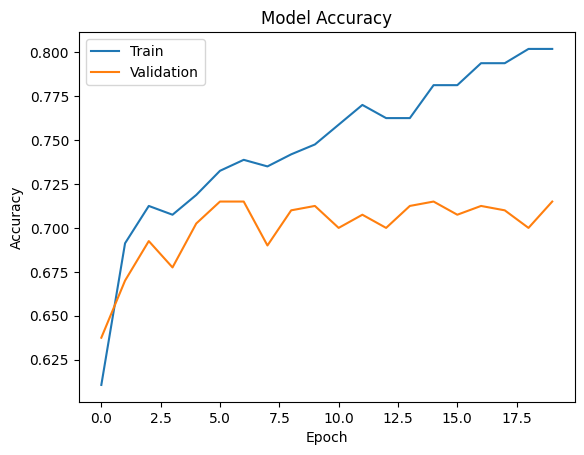

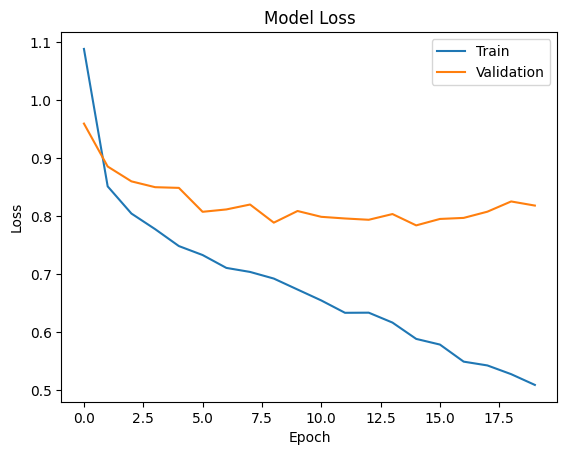

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

#Generating Model Predictions
The trained model predicts the probability of each class for every test image.

In [12]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step


A confusion matrix is a table used to evaluate the performance of a classification model by comparing the actual labels with the predicted labels.

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[170   3   7   1   0]
 [  5  19  22   2   2]
 [  7   8  84   3   4]
 [  4   0  14   5   2]
 [  4   4  21   1   8]]


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92       181
           1       0.56      0.38      0.45        50
           2       0.57      0.79      0.66       106
           3       0.42      0.20      0.27        25
           4       0.50      0.21      0.30        38

    accuracy                           0.71       400
   macro avg       0.59      0.50      0.52       400
weighted avg       0.70      0.71      0.69       400



In [15]:
classes = {
0: "No DR",
1: "Mild",
2: "Moderate",
3: "Severe",
4: "Proliferative DR"
}

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def compare_retina_images(image_paths):

    stages = []
    confidences = []
    probabilities = []

    for path in image_paths:

        img = cv2.imread(path)
        img = cv2.resize(img,(224,224))
        img = img/255.0
        img = np.expand_dims(img,axis=0)

        pred = model.predict(img)

        class_id = np.argmax(pred)
        confidence = np.max(pred)*100

        stages.append(classes[class_id])
        confidences.append(confidence)
        probabilities.append(pred[0])   # store full probability vector

    print("\n====== Retina Comparison Report ======\n")

    for i in range(len(image_paths)):
        print(f"Image {i+1}")
        print("Prediction:", stages[i])
        print("Confidence:", round(confidences[i],2),"%")
        print()

    plt.style.use("dark_background")

    # Plot 1 : Retinopathy Class Distribution

    severity_map = {
        "No DR":0,
        "Mild":1,
        "Moderate":2,
        "Severe":3,
        "Proliferative DR":4
    }

    severity_scores = [severity_map[s] for s in stages]

    plt.figure(figsize=(6,4))

    plt.bar(
        [f"Image {i+1}" for i in range(len(severity_scores))],
        severity_scores
    )

    plt.title("Retinopathy Class Distribution")
    plt.ylabel("Severity Level (0-4)")
    plt.xlabel("Images")

    plt.show()


    # Plot 2 : Probability Distribution

    class_names = ["No DR","Mild","Moderate","Severe","Proliferative"]

    probabilities = np.array(probabilities)

    plt.figure(figsize=(8,5))

    for i in range(len(probabilities)):
        plt.plot(class_names, probabilities[i]*100, marker='o', label=f"Image {i+1}")

    plt.title("Class Probability Distribution Comparison")
    plt.ylabel("Probability (%)")
    plt.xlabel("Retinopathy Class")
    plt.legend()

    plt.show()

    return stages, confidences

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

====== Retina Comparison Report ======

Image 1
Prediction: Moderate
Confidence: 91.78 %

Image 2
Prediction: Mild
Confidence: 60.57 %

Image 3
Prediction: No DR
Confidence: 99.83 %

Image 4
Prediction: Moderate
Confidence: 78.21 %



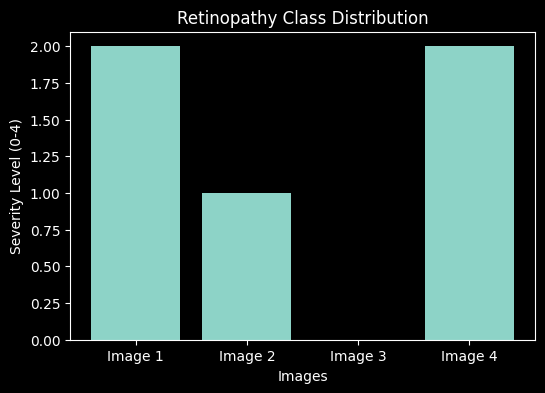

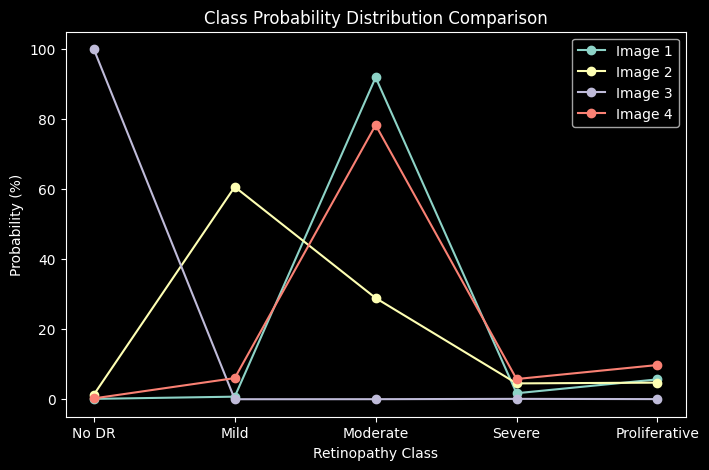

(['Moderate', 'Mild', 'No DR', 'Moderate'],
 [np.float32(91.78474),
  np.float32(60.574936),
  np.float32(99.831894),
  np.float32(78.2051)])

In [18]:
compare_retina_images([

"/content/drive/MyDrive/sic_project/test_images/3a70c2d49381.png",
"/content/drive/MyDrive/sic_project/test_images/636997a49fcb.png",
"/content/drive/MyDrive/sic_project/train_images/005b95c28852.png",
 "/content/drive/MyDrive/sic_project/train_images/001639a390f0.png"
])

In [18]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/sic_project/my_model1.keras")

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")

classes = {
0: "No DR",
1: "Mild",
2: "Moderate",
3: "Severe",
4: "Proliferative DR"
}

def predict_single(img_path):

    # Load Image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb,(224,224))
    img_norm = img_resized / 255.0

    img_input = np.expand_dims(img_norm,axis=0)

    # Prediction
    pred = model.predict(img_input)

    class_id = np.argmax(pred)
    confidence = np.max(pred) * 100

    print("\n====== AI Retinopathy Screening Result ======")
    print("Predicted Class:", classes[class_id])
    print("Confidence: {:.2f}%".format(confidence))

    # Plot 1: Original Image
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {classes[class_id]} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    # Plot 2: Probability Bar Chart
    probs = pred[0] * 100
    labels = list(classes.values())

    plt.figure(figsize=(8,4))
    bars = plt.bar(labels, probs)

    plt.title("Class Probability Distribution")
    plt.ylabel("Probability (%)")
    plt.xticks(rotation=30)

    for i,prob in enumerate(probs):
        plt.text(i,prob+1,f"{prob:.1f}%",ha="center")

    plt.show()

    # Plot 3: Radar / Polar Plot
    angles = np.linspace(0,2*np.pi,len(probs),endpoint=False)
    probs = np.concatenate((probs,[probs[0]]))
    angles = np.concatenate((angles,[angles[0]]))

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, polar=True)

    ax.plot(angles, probs, linewidth=2)
    ax.fill(angles, probs, alpha=0.25)

    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_title("Retinopathy Class Distribution")

    plt.show()

    # Print All Probabilities
    print("\nDetailed Probabilities:")
    for i,p in enumerate(pred[0]):
        print(f"{classes[i]} : {p*100:.2f}%")

    return classes[class_id], confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

====== AI Retinopathy Screening Result ======
Predicted Class: Moderate
Confidence: 78.19%


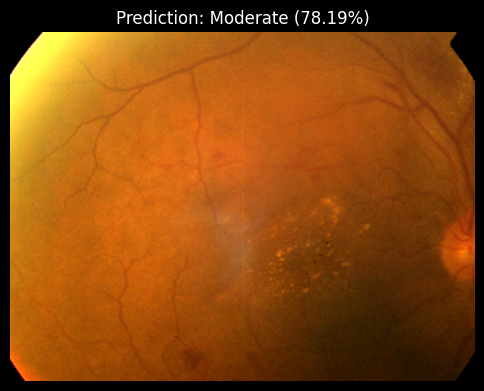

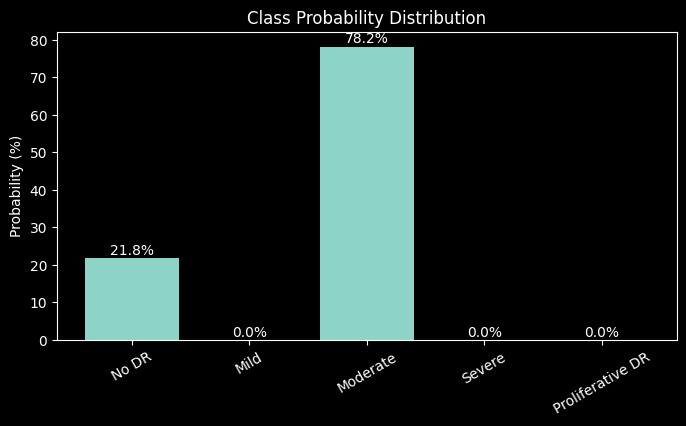

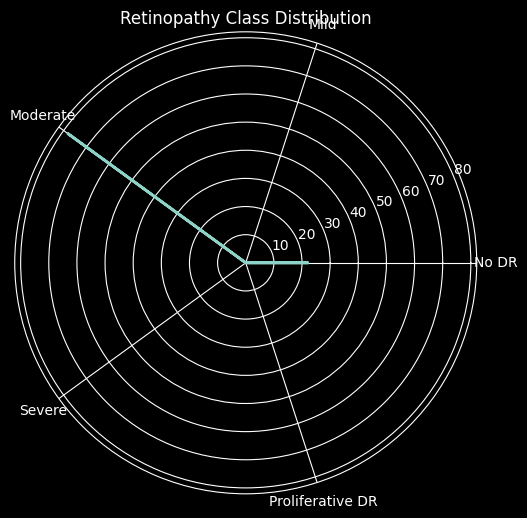


Detailed Probabilities:
No DR : 21.81%
Mild : 0.00%
Moderate : 78.19%
Severe : 0.00%
Proliferative DR : 0.00%


('Moderate', np.float32(78.194084))

In [29]:
predict_single("/content/drive/MyDrive/sic_project/test_images/0005cfc8afb6.png")


In [20]:
# @title
# ══════════════════════════════════════════════════════════════
#   AI Diabetic Retinopathy Screening System  — v2
#   Dark Cobalt Clinical UI  |  Single + Multi-Image Comparison
# ══════════════════════════════════════════════════════════════

import gradio as gr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np
import cv2
import warnings
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────
# DR KNOWLEDGE BASE
# ──────────────────────────────────────────────────────────────
CLASSES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

DR_INFO = {
    "No DR":          {"score":0, "color":"#00e5a0", "risk":"Minimal",  "icd":"E11.319", "urgency":"Routine",          "follow_up":"12 months"},
    "Mild":           {"score":1, "color":"#ffe566", "risk":"Low",      "icd":"E11.321", "urgency":"Soon (3 months)",   "follow_up":"9–12 months"},
    "Moderate":       {"score":2, "color":"#ff9f43", "risk":"Moderate", "icd":"E11.331", "urgency":"Urgent (1 month)",  "follow_up":"6 months"},
    "Severe":         {"score":3, "color":"#ff5e57", "risk":"High",     "icd":"E11.341", "urgency":"Very Urgent",       "follow_up":"3–4 months"},
    "Proliferative":  {"score":4, "color":"#c0392b", "risk":"Critical", "icd":"E11.359", "urgency":"EMERGENCY",         "follow_up":"Immediate"},
}

DR_DETAILS = {
    "No DR": {
        "desc": "No visible diabetic retinopathy. Retina appears structurally healthy with no microvascular damage.",
        "symptoms": ["No visual disturbances","Clear retinal vessels","No macular edema","Full peripheral vision"],
        "treatment": ["Annual dilated eye exam","Continue diabetes management","Monitor HbA1c every 3–6 months"],
        "prevention": ["Maintain HbA1c < 7%","150 min/week aerobic exercise","Low-glycemic balanced diet"],
    },
    "Mild": {
        "desc": "Early-stage DR with microaneurysms — tiny bulges in retinal capillary walls from chronic hyperglycemia.",
        "symptoms": ["Subtle intermittent blur","Occasional contrast sensitivity loss","Generally asymptomatic"],
        "treatment": ["Strict glycemic control (HbA1c ≤ 7%)","Increased ophthalmology monitoring","Fenofibrate may slow progression"],
        "prevention": ["Rigorous glucose monitoring (CGM)","Reduce refined carbohydrates","Annual retinal photography"],
    },
    "Moderate": {
        "desc": "Significant retinal vascular damage with hemorrhages, hard exudates, and early macular changes.",
        "symptoms": ["Blurred/fluctuating central vision","Dark floating spots","Reduced night vision"],
        "treatment": ["Focal laser photocoagulation (if indicated)","Anti-VEGF injections","Intensive glycemic management"],
        "prevention": ["Mediterranean diet","Daily physical activity","OCT + fundus photography every 6 months"],
    },
    "Severe": {
        "desc": "Widespread retinal ischemia — 20+ intraretinal hemorrhages per quadrant, venous beading, IRMA.",
        "symptoms": ["Visual distortion","Large persistent dark spots","Difficulty recognizing objects","Scotomas"],
        "treatment": ["Panretinal laser photocoagulation","Anti-VEGF injections (Ranibizumab)","Monthly retinal specialist visits"],
        "prevention": ["Continuous glucose monitoring","Systolic BP < 120 mmHg","Avoid strenuous activity"],
    },
    "Proliferative": {
        "desc": "Most advanced stage — abnormal neovascularization on retinal surface, high risk of irreversible blindness.",
        "symptoms": ["Sudden significant vision loss","Dense floaters from vitreous hemorrhage","Traction retinal detachment"],
        "treatment": ["Vitrectomy surgery","Extensive panretinal photocoagulation","Intravitreal Aflibercept injections"],
        "prevention": ["Early screening is the ONLY true prevention","Annual fundus photography from diabetes diagnosis"],
    },
}

# ──────────────────────────────────────────────────────────────
# MOCK MODEL  (replace with your real model.predict)
# ──────────────────────────────────────────────────────────────
def predict_single(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224)) / 255.0
    img = np.expand_dims(img, 0)
    # ── stub: replace with  pred = model.predict(img)  ──
    raw   = np.random.dirichlet(np.ones(5) * 0.7)
    stage = CLASSES[np.argmax(raw)]
    conf  = float(np.max(raw)) * 100
    return stage, conf, raw

# ──────────────────────────────────────────────────────────────
# PALETTE HELPERS
# ──────────────────────────────────────────────────────────────
BG      = "#050c1a"
CARD    = "#0b1629"
SURFACE = "#0f1e38"
BORDER  = "#1a3050"
ACCENT  = "#2dd4f7"
ACCENT2 = "#7c6cf8"
TEXT    = "#dde6f5"
MUTED   = "#5a7a9a"

def _fig(w=13, h=5):
    fig = plt.figure(figsize=(w, h), facecolor=BG)
    fig.patch.set_facecolor(BG)
    return fig

def _style_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_facecolor(CARD)
    ax.set_title(title,  color=TEXT,  fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=8)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=8)
    ax.tick_params(colors=MUTED, labelsize=7.5)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    ax.yaxis.grid(True, color=BORDER, linestyle="--", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

# ──────────────────────────────────────────────────────────────
# SINGLE IMAGE — charts
# ──────────────────────────────────────────────────────────────
def single_charts(stage, probs):
    info = DR_INFO[stage]
    accent = info["color"]

    fig = _fig(13, 9)
    gs  = GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.42)

    # 1. Class probability bars
    ax1 = fig.add_subplot(gs[0, :2])
    _style_ax(ax1, "Class Probability Distribution", "DR Stage", "Probability (%)")
    bar_cols = [DR_INFO[c]["color"] for c in CLASSES]
    alphas   = [1.0 if c == stage else 0.35 for c in CLASSES]
    for i, (p, bc, al) in enumerate(zip(probs * 100, bar_cols, alphas)):
        ax1.bar(i, p, color=bc, alpha=al, width=0.6, zorder=3,
                edgecolor="white" if CLASSES[i] == stage else BORDER,
                linewidth=1.8 if CLASSES[i] == stage else 0.8)
        ax1.text(i, p + 0.8, f"{p:.1f}%", ha="center", va="bottom",
                 color=TEXT if CLASSES[i] == stage else MUTED, fontsize=7.5, fontweight="bold")
    ax1.set_xticks(range(5))
    ax1.set_xticklabels(CLASSES, color=MUTED, fontsize=8)
    ax1.set_ylim(0, 115)

    # 2. Severity gauge
    ax2 = fig.add_subplot(gs[0, 2], polar=True)
    ax2.set_facecolor(BG)
    theta = np.linspace(0, np.pi, 300)
    seg_colors = [DR_INFO[c]["color"] for c in CLASSES]
    for i in range(5):
        ax2.fill_between(theta[i*60:(i+1)*60+1], 0.55, 1.0, color=seg_colors[i], alpha=0.85)
    needle = np.pi * (1 - info["score"] / 4)
    ax2.annotate("", xy=(needle, 0.82), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color="white", lw=2.5, mutation_scale=18))
    ax2.set_ylim(0, 1.1); ax2.set_xlim(0, np.pi); ax2.axis("off")
    ax2.text(np.pi/2, -0.28, "Severity", ha="center", color=MUTED, fontsize=8.5)
    ax2.text(np.pi/2, -0.52, info["risk"], ha="center", color=accent, fontsize=12, fontweight="bold")

    # 3. Risk factor bars
    ax3 = fig.add_subplot(gs[1, :2])
    _style_ax(ax3, "Estimated Risk Indicators", "", "Risk Level (%)")
    rfactors = ["Blood Sugar", "Blood Pressure", "Cholesterol", "Diabetes\nDuration", "BMI", "Kidney Fn"]
    base     = [55, 45, 35, 42, 32, 28]
    vals     = np.clip([b + info["score"]*10 + np.random.randint(-5, 8) for b in base], 10, 99)
    rcols    = [accent if v > 70 else "#3b82f6" if v > 50 else "#22c55e" for v in vals]
    for xi, (v, rc) in enumerate(zip(vals, rcols)):
        ax3.bar(xi, v, color=rc, width=0.55, zorder=3, edgecolor=BORDER, linewidth=0.8)
        ax3.text(xi, v + 1.2, f"{v}%", ha="center", va="bottom", color=TEXT, fontsize=7, fontweight="bold")
    ax3.set_xticks(range(len(rfactors)))
    ax3.set_xticklabels(rfactors, color=MUTED, fontsize=7.5)
    ax3.set_ylim(0, 115)

    # 4. HbA1c trend
    ax4 = fig.add_subplot(gs[1, 2])
    _style_ax(ax4, "Simulated HbA1c Trend", "Month", "HbA1c (%)")
    months = np.arange(1, 13)
    base_hba = 6.5 + info["score"] * 0.6
    hba  = np.clip(base_hba + np.cumsum(np.random.randn(12) * 0.18), 5.5, 13)
    ax4.fill_between(months, hba, alpha=0.2, color=accent)
    ax4.plot(months, hba, color=accent, lw=2, marker="o", markersize=3.5, markerfacecolor=BG)
    ax4.axhline(7.0, color="#22c55e", linestyle="--", lw=1, alpha=0.8, label="Target <7%")
    leg = ax4.legend(fontsize=7, facecolor=CARD, edgecolor=BORDER)
    for t in leg.get_texts(): t.set_color(MUTED)

    plt.suptitle(f"Clinical Dashboard — {stage}  ({info['risk']} Risk)",
                 color=TEXT, fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    return fig

# ──────────────────────────────────────────────────────────────
# SINGLE IMAGE — report text
# ──────────────────────────────────────────────────────────────
def single_report(stage, conf, probs):
    info = DR_INFO[stage]
    det  = DR_DETAILS[stage]
    bar  = "█" * (info["score"]+1) + "░" * (4-info["score"])
    s_md = "\n".join(f"  - {x}" for x in det["symptoms"])
    t_md = "\n".join(f"  - {x}" for x in det["treatment"])
    p_md = "\n".join(f"  - {x}" for x in det["prevention"])
    return f"""
# 🔬 AI Retinopathy Screening Report

| Field | Value |
|---|---|
| **Stage Detected** | {stage} |
| **Confidence** | {conf:.1f}% |
| **Risk Level** | {info['risk']} |
| **Severity** | `{bar}` ({info['score']}/4) |
| **ICD-10** | `{info['icd']}` |
| **Follow-up** | {info['follow_up']} |
| **⚡ Urgency** | **{info['urgency']}** |

---

> {det['desc']}

---
## ⚠️ Symptoms
{s_md}

## 💊 Treatment
{t_md}

## 🛡️ Prevention
{p_md}

---
> ⚠️ AI screening tool — not a substitute for professional diagnosis.
"""

# ──────────────────────────────────────────────────────────────
# COMPARISON — charts
# ──────────────────────────────────────────────────────────────
def comparison_charts(stages, confs, all_probs, n):
    fig = _fig(14, 10)
    gs  = GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.38)

    img_labels = [f"Img {i+1}" for i in range(n)]
    score_vals = [DR_INFO[s]["score"] for s in stages]
    bar_colors = [DR_INFO[s]["color"] for s in stages]

    # 1. Severity bar
    ax1 = fig.add_subplot(gs[0, 0])
    _style_ax(ax1, "Severity Score per Image", "Image", "Severity (0–4)")
    bars = ax1.bar(img_labels, score_vals, color=bar_colors, width=0.5, zorder=3,
                   edgecolor=BORDER, linewidth=0.9)
    for bar, sv, st in zip(bars, score_vals, stages):
        ax1.text(bar.get_x()+bar.get_width()/2, sv+0.05, st,
                 ha="center", va="bottom", color=TEXT, fontsize=7.5, fontweight="bold")
    ax1.set_ylim(0, 5.5)

    # 2. Confidence bar
    ax2 = fig.add_subplot(gs[0, 1])
    _style_ax(ax2, "Model Confidence per Image", "Image", "Confidence (%)")
    ax2.bar(img_labels, confs, color=ACCENT, width=0.5, zorder=3,
            edgecolor=BORDER, linewidth=0.8, alpha=0.85)
    for i, c in enumerate(confs):
        ax2.text(i, c+0.8, f"{c:.1f}%", ha="center", va="bottom",
                 color=TEXT, fontsize=7.5, fontweight="bold")
    ax2.set_ylim(0, 115)

    # 3. Probability line comparison
    ax3 = fig.add_subplot(gs[1, :])
    _style_ax(ax3, "Class Probability Distribution — All Images", "DR Stage", "Probability (%)")
    line_colors = [DR_INFO[s]["color"] for s in stages]
    x = np.arange(5)
    for i, (prob_row, lc) in enumerate(zip(all_probs, line_colors)):
        ax3.plot(x, prob_row * 100, marker="o", lw=2, markersize=5,
                 color=lc, label=f"Img {i+1}: {stages[i]}", zorder=3,
                 markerfacecolor=BG, markeredgecolor=lc, markeredgewidth=1.5)
        ax3.fill_between(x, prob_row * 100, alpha=0.06, color=lc)
    ax3.set_xticks(x)
    ax3.set_xticklabels(CLASSES, color=MUTED, fontsize=8.5)
    ax3.set_ylim(0, 110)
    leg = ax3.legend(fontsize=8, facecolor=CARD, edgecolor=BORDER,
                     loc="upper right", ncol=min(n, 4))
    for t in leg.get_texts(): t.set_color(TEXT)

    plt.suptitle("Multi-Image Retinal Comparison Dashboard",
                 color=TEXT, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    return fig

# ──────────────────────────────────────────────────────────────
# COMPARISON — report text
# ──────────────────────────────────────────────────────────────
def comparison_report(stages, confs, n):
    rows = "\n".join(
        f"| **Image {i+1}** | {stages[i]} | {confs[i]:.1f}% | "
        f"{DR_INFO[stages[i]]['risk']} | {DR_INFO[stages[i]]['urgency']} |"
        for i in range(n)
    )
    worst_idx = int(np.argmax([DR_INFO[s]["score"] for s in stages]))
    worst     = stages[worst_idx]
    wi        = DR_INFO[worst]
    avg_sev   = np.mean([DR_INFO[s]["score"] for s in stages])

    return f"""
# 🔁 Multi-Image Comparison Report

## 📊 Summary Table

| Image | Stage | Confidence | Risk | Urgency |
|---|---|---|---|---|
{rows}

---

## 🔺 Most Severe Finding

**Image {worst_idx+1} — {worst}**
> {DR_DETAILS[worst]['desc']}

**Recommended action:** {wi['urgency']} · Follow-up in **{wi['follow_up']}**

---

## 📈 Overall Assessment

- **Images analysed:** {n}
- **Average severity score:** {avg_sev:.2f} / 4
- **Highest severity detected:** {worst} (Score {wi['score']}/4)
- **Unique stages found:** {", ".join(sorted(set(stages)))}

---

> ⚠️ AI tool only — always confirm findings with a licensed retinal specialist.
"""

# ──────────────────────────────────────────────────────────────
# GRADIO CALLBACKS
# ──────────────────────────────────────────────────────────────
def run_single(image):
    if image is None:
        return "⚠️ Please upload an image.", None
    stage, conf, probs = predict_single(image)
    report = single_report(stage, conf, probs)
    chart  = single_charts(stage, probs)
    return report, chart

def run_comparison(*images):
    imgs = [im for im in images if im is not None]
    if len(imgs) < 2:
        return "⚠️ Upload at least 2 images to compare.", None
    stages, confs, all_probs = [], [], []
    for path in imgs:
        s, c, p = predict_single(path)
        stages.append(s); confs.append(c); all_probs.append(p)
    report = comparison_report(stages, confs, len(imgs))
    chart  = comparison_charts(stages, confs, all_probs, len(imgs))
    return report, chart

# ──────────────────────────────────────────────────────────────
# CSS
# ──────────────────────────────────────────────────────────────
CSS = """
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=IBM+Plex+Mono:wght@400;600&display=swap');

:root {
    --bg:      #050c1a;
    --card:    #0b1629;
    --surf:    #0f1e38;
    --border:  #1a3050;
    --accent:  #2dd4f7;
    --accent2: #7c6cf8;
    --ok:      #00e5a0;
    --warn:    #ffe566;
    --danger:  #ff5e57;
    --text:    #dde6f5;
    --muted:   #5a7a9a;
    --ff:      'Syne', sans-serif;
    --mono:    'IBM Plex Mono', monospace;
}

*, body { box-sizing:border-box; }

body, .gradio-container {
    background: var(--bg) !important;
    font-family: var(--ff) !important;
    color: var(--text) !important;
    min-height: 100vh;
}

/* ─ Tabs ─ */
.tab-nav button {
    font-family: var(--ff) !important;
    font-size: 0.82rem !important;
    font-weight: 600 !important;
    letter-spacing: 0.06em !important;
    text-transform: uppercase !important;
    color: var(--muted) !important;
    background: transparent !important;
    border: none !important;
    border-bottom: 2px solid transparent !important;
    padding: 0.55rem 1.2rem !important;
    transition: all 0.2s !important;
}
.tab-nav button.selected, .tab-nav button:hover {
    color: var(--accent) !important;
    border-bottom-color: var(--accent) !important;
}

/* ─ Panels / cards ─ */
.panel, .gr-panel, .contain, .block {
    background: var(--card) !important;
    border: 1px solid var(--border) !important;
    border-radius: 14px !important;
}

/* ─ Image upload ─ */
.upload-container, [data-testid="image"], .gr-image {
    background: var(--surf) !important;
    border: 2px dashed var(--border) !important;
    border-radius: 10px !important;
    transition: border-color 0.25s !important;
}
.upload-container:hover, [data-testid="image"]:hover {
    border-color: var(--accent) !important;
}

/* ─ Button ─ */
button.primary, .gr-button-primary, button[variant="primary"] {
    font-family: var(--ff) !important;
    font-size: 0.88rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.05em !important;
    text-transform: uppercase !important;
    background: linear-gradient(135deg, #0ea5e9 0%, #7c6cf8 100%) !important;
    border: none !important;
    border-radius: 10px !important;
    padding: 0.65rem 1.6rem !important;
    color: white !important;
    box-shadow: 0 4px 18px rgba(45,212,247,0.25) !important;
    transition: all 0.2s ease !important;
}
button.primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 26px rgba(45,212,247,0.38) !important;
}

/* ─ Markdown ─ */
.gr-markdown, [data-testid="markdown"] {
    font-family: var(--ff) !important;
    color: var(--text) !important;
    background: var(--card) !important;
    border: 1px solid var(--border) !important;
    border-radius: 12px !important;
    padding: 1.2rem 1.4rem !important;
    height: 520px !important;
    overflow-y: auto !important;
    line-height: 1.7 !important;
    font-size: 0.9rem !important;
}
.gr-markdown h1 {
    font-size: 1.3rem !important;
    color: var(--accent) !important;
    border-bottom: 1px solid var(--border) !important;
    padding-bottom: 0.4rem !important;
}
.gr-markdown h2 { color: var(--accent2) !important; font-size: 1rem !important; margin-top: 1.2rem !important; }
.gr-markdown table { width:100% !important; border-collapse:collapse !important; font-size:0.85rem !important; margin: 0.75rem 0 !important; }
.gr-markdown th { background:var(--surf) !important; color:var(--accent) !important; padding:0.5rem 0.9rem !important; border:1px solid var(--border) !important; font-weight:700 !important; }
.gr-markdown td { padding:0.45rem 0.9rem !important; border:1px solid var(--border) !important; }
.gr-markdown tr:hover td { background:var(--surf) !important; }
.gr-markdown blockquote { border-left:3px solid var(--accent) !important; margin:0.5rem 0 !important; padding:0.4rem 0.8rem !important; background:var(--surf) !important; border-radius:0 6px 6px 0 !important; color:var(--muted) !important; }
.gr-markdown code { font-family:var(--mono) !important; background:var(--surf) !important; color:var(--warn) !important; padding:0.1rem 0.4rem !important; border-radius:4px !important; font-size:0.82rem !important; }
.gr-markdown hr { border-color:var(--border) !important; }
.gr-markdown li { margin:0.25rem 0 !important; }

/* ─ Labels ─ */
label, .label { color:var(--muted) !important; font-size:0.78rem !important; text-transform:uppercase !important; letter-spacing:0.07em !important; font-weight:600 !important; }

/* ─ Scrollbar ─ */
::-webkit-scrollbar { width:5px; }
::-webkit-scrollbar-track { background:var(--bg); }
::-webkit-scrollbar-thumb { background:var(--border); border-radius:3px; }
::-webkit-scrollbar-thumb:hover { background:var(--accent); }

footer { display:none !important; }
"""

# ──────────────────────────────────────────────────────────────
# LAYOUT
# ──────────────────────────────────────────────────────────────
HEADER = """
<div style="
    text-align:center;
    padding:2rem 1rem 1.4rem;
    background:linear-gradient(180deg,#050c1a 0%,#0b1629 100%);
    border-bottom:1px solid #1a3050;
">
    <div style="font-size:2.6rem;margin-bottom:0.4rem;">🔬</div>
    <h1 style="
        font-family:'Syne',sans-serif;font-size:1.9rem;font-weight:800;
        background:linear-gradient(135deg,#2dd4f7,#7c6cf8);
        -webkit-background-clip:text;-webkit-text-fill-color:transparent;
        margin:0 0 0.4rem;letter-spacing:-0.02em;
    ">Diabetic Retinopathy AI Screening</h1>
    <p style="color:#5a7a9a;font-family:'Syne',sans-serif;font-size:0.9rem;max-width:560px;margin:0 auto;line-height:1.6;">
        Upload retinal fundus images for instant AI-powered DR staging, clinical analytics, and multi-image comparison.
    </p>
    <div style="display:flex;justify-content:center;gap:1rem;margin-top:1rem;flex-wrap:wrap;">
        <span style="background:#0b1629;border:1px solid #1a3050;border-radius:7px;padding:0.28rem 0.8rem;color:#2dd4f7;font-size:0.75rem;font-family:'Syne',sans-serif;">⚡ 5-Stage Classification</span>
        <span style="background:#0b1629;border:1px solid #1a3050;border-radius:7px;padding:0.28rem 0.8rem;color:#7c6cf8;font-size:0.75rem;font-family:'Syne',sans-serif;">📊 Clinical Analytics</span>
        <span style="background:#0b1629;border:1px solid #1a3050;border-radius:7px;padding:0.28rem 0.8rem;color:#00e5a0;font-size:0.75rem;font-family:'Syne',sans-serif;">🔁 Multi-Image Compare</span>
        <span style="background:#0b1629;border:1px solid #1a3050;border-radius:7px;padding:0.28rem 0.8rem;color:#ffe566;font-size:0.75rem;font-family:'Syne',sans-serif;">🏥 ICD-10 Coded</span>
    </div>
</div>
"""

FOOTER = """
<div style="text-align:center;padding:1.1rem;color:#2a4060;font-family:'Syne',sans-serif;font-size:0.75rem;border-top:1px solid #1a3050;margin-top:1rem;">
    ⚠️ For research & educational use only · Not a substitute for professional medical diagnosis · Consult a licensed ophthalmologist
</div>
"""

with gr.Blocks(css=CSS, theme=gr.themes.Base()) as app:

    gr.HTML(HEADER)

    with gr.Tabs():

        # ── TAB 1 : Single Image ──────────────────────────
        with gr.Tab("🔍  Single Image Analysis"):
            with gr.Row(equal_height=False):
                with gr.Column(scale=1, min_width=240):
                    img_single = gr.Image(type="filepath", label="Retinal Fundus Image", height=240)
                    gr.HTML("""
                    <div style="background:#0f1e38;border:1px solid #1a3050;border-radius:9px;padding:0.9rem 1rem;margin-top:0.6rem;font-family:'Syne',sans-serif;">
                        <div style="color:#2dd4f7;font-size:0.72rem;font-weight:700;text-transform:uppercase;letter-spacing:0.08em;margin-bottom:0.5rem;">Supported</div>
                        <div style="color:#5a7a9a;font-size:0.82rem;line-height:1.7;">• Color fundus photos (CFP)<br>• JPEG / PNG / TIFF<br>• Min 512×512 px recommended</div>
                    </div>""")
                    btn_single = gr.Button("Analyze →", variant="primary", size="lg")

                with gr.Column(scale=2):
                    out_report_s = gr.Markdown(label="Clinical Report")

            out_chart_s = gr.Plot(label="Clinical Analytics Dashboard")
            btn_single.click(run_single, inputs=[img_single], outputs=[out_report_s, out_chart_s])

        # ── TAB 2 : Multi-Image Comparison ───────────────
        with gr.Tab("🔁  Multi-Image Comparison"):
            gr.HTML("""<div style="color:#5a7a9a;font-family:'Syne',sans-serif;font-size:0.82rem;padding:0.5rem 0 0.9rem;">
                Upload 2–4 retinal images to compare predictions, severity scores, and probability distributions side-by-side.
            </div>""")
            with gr.Row():
                img_c1 = gr.Image(type="filepath", label="Image 1", height=185)
                img_c2 = gr.Image(type="filepath", label="Image 2", height=185)
                img_c3 = gr.Image(type="filepath", label="Image 3 (opt.)", height=185)
                img_c4 = gr.Image(type="filepath", label="Image 4 (opt.)", height=185)

            btn_cmp = gr.Button("Compare All →", variant="primary")

            with gr.Row():
                out_report_c = gr.Markdown(label="Comparison Report")
            out_chart_c = gr.Plot(label="Comparison Dashboard")

            btn_cmp.click(run_comparison,
                          inputs=[img_c1, img_c2, img_c3, img_c4],
                          outputs=[out_report_c, out_chart_c])

    gr.HTML(FOOTER)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c4820b3f88587d384.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [64]:
# ▶ Data Preprocessing